In [1]:
!pip install numpy matplotlib scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset shape:", X.shape)

Dataset shape: (1797, 64)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1437
Testing samples: 360


In [5]:
rf_params = {
    "n_estimators":[50,100,200],
    "max_depth":[10,20,None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(oob_score=True, random_state=42),
    rf_params,
    cv=3
)

rf_grid.fit(X_train, y_train)

rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 200}


In [6]:
start = time.time()

rf.fit(X_train, y_train)

rf_train_time = time.time() - start

start = time.time()

y_pred_rf = rf.predict(X_test)

rf_pred_time = time.time() - start

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("OOB Error:", 1 - rf.oob_score_)

Random Forest Accuracy: 0.9722222222222222
OOB Error: 0.02783576896311757


In [7]:
base_tree = DecisionTreeClassifier(max_depth=1)

In [8]:
ada_params = {
    "n_estimators":[50,100,200],
    "learning_rate":[0.1,0.5,1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=base_tree, random_state=42),
    ada_params,
    cv=3
)

ada_grid.fit(X_train, y_train)

ada = ada_grid.best_estimator_

print("Best Parameters:", ada_grid.best_params_)

Best Parameters: {'learning_rate': 1.0, 'n_estimators': 200}


In [9]:
start = time.time()

ada.fit(X_train, y_train)

ada_train_time = time.time() - start

start = time.time()

y_pred_ada = ada.predict(X_test)

ada_pred_time = time.time() - start

ada_accuracy = accuracy_score(y_test, y_pred_ada)

print("AdaBoost Accuracy:", ada_accuracy)

AdaBoost Accuracy: 0.8638888888888889


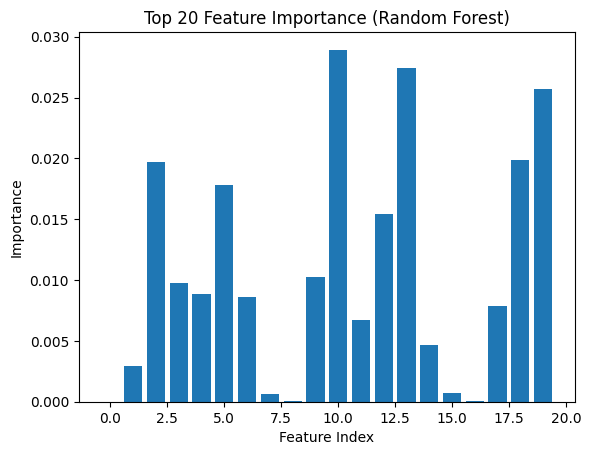

In [10]:
importance = rf.feature_importances_

plt.bar(range(20), importance[:20])

plt.title("Top 20 Feature Importance (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.show()

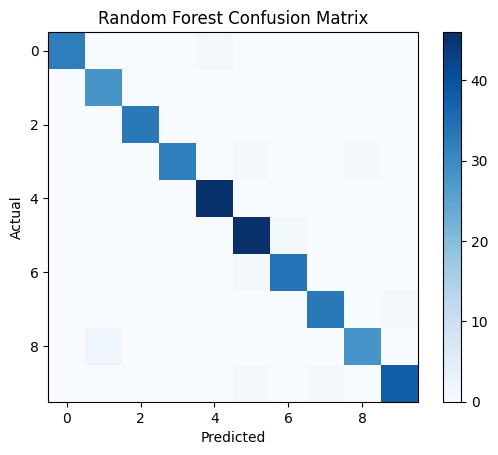

In [11]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.imshow(cm_rf, cmap="Blues")
plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

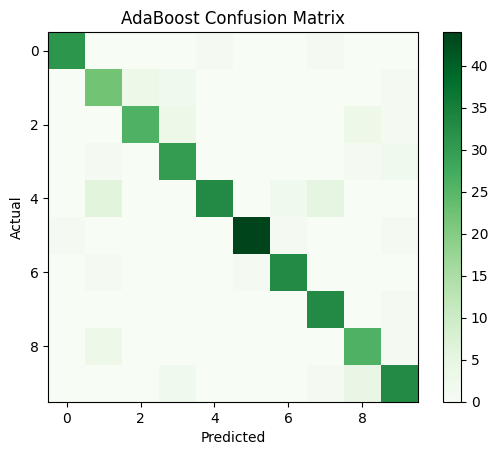

In [12]:
cm_ada = confusion_matrix(y_test, y_pred_ada)

plt.imshow(cm_ada, cmap="Greens")
plt.title("AdaBoost Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
print("Performance Comparison")

print("Random Forest Accuracy:", rf_accuracy)
print("AdaBoost Accuracy:", ada_accuracy)

print("Random Forest Training Time:", rf_train_time)
print("AdaBoost Training Time:", ada_train_time)

print("Random Forest Prediction Time:", rf_pred_time)
print("AdaBoost Prediction Time:", ada_pred_time)

Performance Comparison
Random Forest Accuracy: 0.9722222222222222
AdaBoost Accuracy: 0.8638888888888889
Random Forest Training Time: 1.0154132843017578
AdaBoost Training Time: 1.0636208057403564
Random Forest Prediction Time: 0.024471759796142578
AdaBoost Prediction Time: 0.04979205131530762
